# Exploring data sources for ERA5

## Our prepackaged example data

We have 12 hours of hourly sea level pressure data extracted from ERA5

In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("data/SLP_ex.nc")
da = ds["SLP"]
da

<xarray.DataArray 'SLP' (time: 13, latitude: 181, longitude: 360)> Size: 7MB
[847080 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Attributes:
    standard_name:  air_pressure_at_mean_sea_level
    long_name:      Mean sea level pressure
    units:          Pa

### A reference plot

Just plot the first time step

In [20]:
ref_time = da.time[0]

<xarray.DataArray 'time' ()> Size: 8B
array('2022-11-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2022-11-01
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T

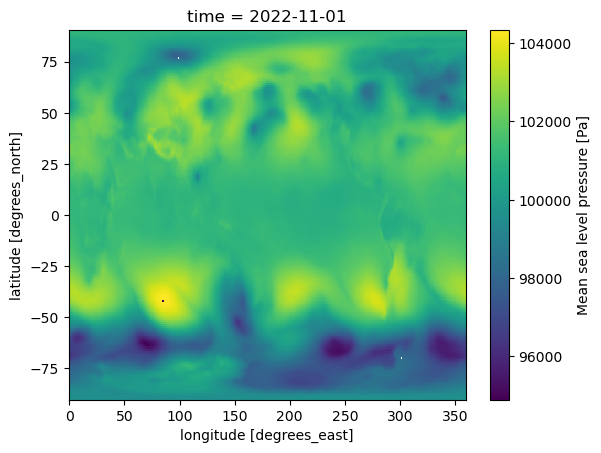

In [21]:
da.sel(time=ref_time).plot()

## Streaming ERA5 data from Earthmover

This requires a per-user login (need to create a free account in advance)

But we can easily recreate the same data slice and the same reference plot.

In [4]:
from arraylake import Client
client = Client()

In [5]:
client.login()

Successfully refreshed tokens! Token stored at /Users/brianrose/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: brose@albany.edu                                                                                         │
│ Id: 42b3a5b8-e618-4e14-aba8-632532f16692                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [6]:
repo = client.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")

In [7]:
ds_spatial = xr.open_zarr(session.store, group="single/spatial", chunks=None)

This has grabbed a live handle to a really vast amount of data:

In [8]:
ds_spatial

<xarray.Dataset> Size: 110TB
Dimensions:     (valid_time: 753888, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Data variables: (12/35)
    cape        (valid_time, latitude, longitude) float32 3TB ...
    blh         (valid_time, latitude, longitude) float32 3TB ...
    fg10        (valid_time, latitude, longitude) float32 3TB ...
    ie          (valid_time, latitude, longitude) float32 3TB ...
    cp          (valid_time, latitude, longitude) float32 3TB ...
    d2m         (valid_time, latitude, longitude) float32 3TB ...
    ...          ...
    v100        (valid_time, latitude, longitude) float32 3TB ...
    tisr        (valid_time, latitude, longitude) float32 3TB ...
    u100        (valid_time, latitude, longitude) float32 3TB ...
    v10         (valid_time, latitude, longitude) float32 3TB ...
    tsr         (valid_time, latitude, longitude) float32 3TB ...
    zust        (valid_time, latitude, longitude) float32 3TB ...
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-10T20:01 GRIB to CDM+CF via cfgrib-0....

The sea level pressure data is in here in variable `msl`:

In [9]:
ds_spatial.msl.GRIB_cfName

'air_pressure_at_mean_sea_level'

We can easily subset the exact same slice of sea level pressure data as our pre-loaded file:

In [10]:
ds_spatial.msl.sel(valid_time=da.time)

<xarray.DataArray 'msl' (time: 13, latitude: 721, longitude: 1440)> Size: 54MB
[13497120 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
    valid_time  (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Attributes: (12/32)
    GRIB_paramId:                             151
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    long_name:                                Mean sea level pressure
    units:                                    Pa
    standard_name:                            air_pressure_at_mean_sea_level
    GRIB_surface:                             0.0

### Recreate the reference plot, this time from streamed data

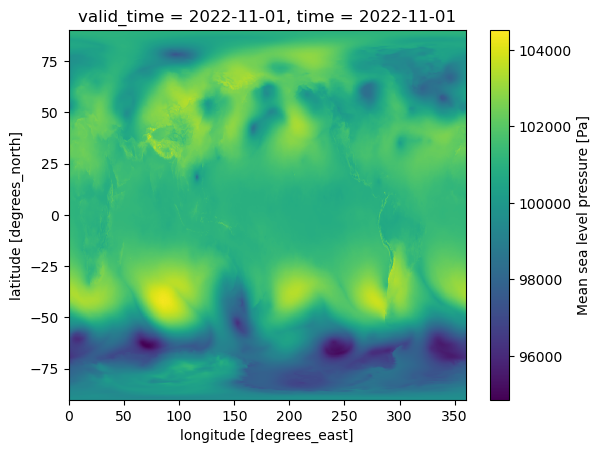

In [22]:
ds_spatial.msl.sel(valid_time=ref_time).plot()

## Streaming ERA5 from a login-free source

Here we're pulling data from NSF NCAR GDEX

In [12]:
filename = 'https://osdf-director.osg-htc.org/ncar/gdex/d633000/e5.oper.an.sfc.zarr/e5.oper.an.sfc.msl.zarr'
msl = xr.open_dataset(filename, engine='zarr')
msl

<xarray.Dataset> Size: 3TB
Dimensions:            (time: 749472, latitude: 721, longitude: 1440)
Coordinates:
  * time               (time) datetime64[ns] 6MB 1940-01-01 ... 2025-06-30T23...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    MSL                (time, latitude, longitude) float32 3TB ...
    quantization_info  |S1 1B ...
    utc_date           (time) int32 3MB ...
Attributes:
    CONVERSION_DATE:      Mon 01 Sep 2025 03:17:47 PM MDT
    CONVERSION_PLATFORM:  Linux crhtc71 5.14.21-150400.24.46-default #1 SMP P...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    history:              Mon Sep  1 15:27:57 2025: ncks -4 -L 1 --baa=0 --pp...

In [13]:
msl.MSL.sel(time=da.time)

<xarray.DataArray 'MSL' (time: 13, latitude: 721, longitude: 1440)> Size: 54MB
[13497120 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/14)
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7
    ecmwf_local_table:                                  128
    ecmwf_parameter:                                    151
    grid_specification:                                 0.25 degree x 0.25 de...
    long_name:                                          Mean sea level pressure
    maximum_value:                                      106987.5625
    ...                                                 ...
    rda_dataset:                                        ds633.0
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    short_name:                                         msl
    units:                                              Pa

### Recreate the reference figure

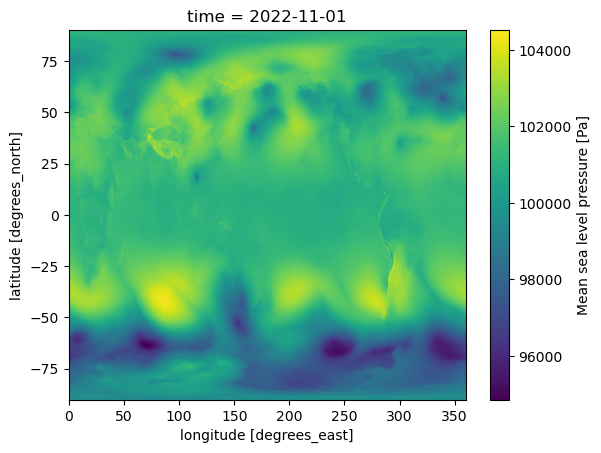

In [23]:
msl.MSL.sel(time=ref_time).plot()

## Google Cloud version seems problematic

In [15]:
import fsspec
fs = fsspec.filesystem('gs')
fs.ls('gs://gcp-public-data-arco-era5/co')

Could not determine bucket type for bucket name gcp-public-data-arco-era5: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem


['gcp-public-data-arco-era5/co/model-level-moisture.zarr',
 'gcp-public-data-arco-era5/co/model-level-moisture.zarr-v2',
 'gcp-public-data-arco-era5/co/model-level-wind.zarr',
 'gcp-public-data-arco-era5/co/model-level-wind.zarr-v2',
 'gcp-public-data-arco-era5/co/single-level-forecast.zarr',
 'gcp-public-data-arco-era5/co/single-level-forecast.zarr-v2',
 'gcp-public-data-arco-era5/co/single-level-reanalysis.zarr',
 'gcp-public-data-arco-era5/co/single-level-reanalysis.zarr-v2',
 'gcp-public-data-arco-era5/co/single-level-surface.zarr',
 'gcp-public-data-arco-era5/co/single-level-surface.zarr-v2']

In [16]:
reanalysis = xr.open_zarr(
    'gs://gcp-public-data-arco-era5/co/single-level-reanalysis.zarr', 
    chunks=None
)

Could not determine bucket type for bucket name gcp-public-data-arco-era5: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name gcp-public-data-arco-era5: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name gcp-public-data-arco-era5: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information., falling back to GCSFileSystem
Could not determine bucket type for bucket name gcp-public-data-arco-era5: Your default credentials were not found. To set up Application Default Credentials

In [17]:
reanalysis

<xarray.Dataset> Size: 31TB
Dimensions:              (time: 374016, values: 542080)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 1979-01-01 ... 2021-08-31T...
    valid_time           (time) datetime64[ns] 3MB ...
    latitude             (values) float64 4MB ...
    longitude            (values) float64 4MB ...
    depthBelowLandLayer  float64 8B ...
    entireAtmosphere     float64 8B ...
    number               int64 8B ...
    step                 int64 8B ...
    surface              float64 8B ...
Dimensions without coordinates: values
Data variables: (12/38)
    cape                 (time, values) float32 811GB ...
    d2m                  (time, values) float32 811GB ...
    hcc                  (time, values) float32 811GB ...
    istl1                (time, values) float32 811GB ...
    istl2                (time, values) float32 811GB ...
    istl3                (time, values) float32 811GB ...
    ...                   ...
    tsn                  (time, values) float32 811GB ...
    u10                  (time, values) float32 811GB ...
    u100                 (time, values) float32 811GB ...
    v10                  (time, values) float32 811GB ...
    v100                 (time, values) float32 811GB ...
    z                    (time, values) float32 811GB ...
Attributes:
    Conventions:               CF-1.7
    GRIB_centre:               ecmf
    GRIB_centreDescription:    European Centre for Medium-Range Weather Forec...
    GRIB_edition:              1
    GRIB_subCentre:            0
    history:                   2022-09-23T18:56 GRIB to CDM+CF via cfgrib-0.9...
    institution:               European Centre for Medium-Range Weather Forec...
    pangeo-forge:inputs_hash:  5f4378143e9f42402424280b63472752da3aa79179b53b...
    pangeo-forge:recipe_hash:  0c3415923e347ce9dac9dc5c6d209525f4d45d799bd25b...
    pangeo-forge:version:      0.9.1

A problem is that this dataset ends in 2021 so doesn't include our reference date:

In [24]:
reanalysis.msl.sel(time=ref_time)

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."